# Buy Box e Margem: o que os dados dizem sobre maximizar exposicao sem sacrificar margem

**Data da analise:** 2026-09-12 · **Painel:** 22 dias (2026-08-22 a 2026-09-12) · **Fonte:** `market_offers` no R2

---

## A pergunta de negocio

O cliente quer **maximizar o tempo em que seus SKUs ficam na buy box**, porque exposicao gera
volume, e volume nas condicoes certas gera margem. O jeito obvio de ganhar exposicao e baixar
preco - e o jeito obvio de destruir margem tambem. A pergunta util nao e "como ganhar a buy box"
e sim:

> **Qual o preco que maximiza o lucro esperado, dado o custo de fornecedor e a probabilidade de
> ganhar a buy box naquele preco?**

Isso so tem resposta se soubermos duas coisas que hoje o sistema nao modela:

1. **Como o preco se converte em probabilidade de buy box** - e se existem alavancas que nao sejam preco.
2. **Onde fica o piso real de margem** - que depende do custo de compra, nao de um numero escolhido a mao.

Este notebook ataca as duas, nesta ordem, e termina num otimizador que junta as duas pontas.

## Resumo dos achados

| # | Hipotese | Veredito | Numero |
|---|----------|----------|--------|
| H1 | A buy box nao e leilao puro de preco | **Confirmada** | 22,0% dos vencedores nao sao o mais barato |
| H2 | Atributos operacionais tem "preco-sombra" | **Confirmada** | FULL vale **+8,5%** de preco (IC95% 6,1-11,0%) |
| H3 | Exposicao e um ativo duravel, nao um flash | **Confirmada** | Retencao diaria 87,0%; FULL 89,9% vs 84,2% |
| H4 | O piso de margem atual nao tem base de custo | **Confirmada** | `min_price` e arbitrario; trava 3 de 4 SKUs |

**A tese central:** hoje o repricer so tem uma alavanca (preco) e um freio sem fundamento
(`min_price`). Os dados mostram uma segunda alavanca que **aumenta exposicao e margem ao mesmo
tempo** - logistica FULL - e permitem trocar o freio arbitrario por um piso calculado.

---
## 1. Setup e carga

In [1]:
import sys, io, os, logging, warnings
warnings.filterwarnings("ignore")
logging.disable(logging.INFO)

# o notebook vive em notebooks/; os modulos de storage vivem em etl/
ETL = os.path.abspath(os.path.join(os.getcwd(), "..", "etl"))
if ETL not in sys.path:
    sys.path.insert(0, ETL)

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from storage.r2 import get_client, download_bytes
from src.config import R2_BUCKET

print("polars", pl.__version__, "| bucket:", R2_BUCKET)

polars 1.43.2 | bucket: orus-github-actions


In [2]:
# --- paleta (validada com scripts/validate_palette.js da skill dataviz) ---
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA2, GRADE = "#0b0b0b", "#52514e", "#e5e4e0"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRADE, "axes.labelcolor": TINTA2, "axes.titlecolor": TINTA,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": TINTA2, "ytick.color": TINTA2,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110, "lines.linewidth": 2,
})

def limpa(ax):
    """Grade recessiva so no eixo Y, atras dos dados."""
    ax.set_axisbelow(True); ax.xaxis.grid(False)
    return ax

In [3]:
def listar(prefixo):
    c = get_client(); chaves = []; tok = None
    while True:
        kw = dict(Bucket=R2_BUCKET, Prefix=prefixo)
        if tok: kw["ContinuationToken"] = tok
        r = c.list_objects_v2(**kw)
        chaves += [o["Key"] for o in r.get("Contents", [])]
        if not r.get("IsTruncated"): break
        tok = r.get("NextContinuationToken")
    return sorted(chaves)

todas = listar("market_offers/")
# alguns dias tem mais de um snapshot (re-runs). Manter 1 por dia, senao o painel
# da secao 5 compara o dia consigo mesmo e INFLA a retencao artificialmente.
por_dia = {}
for k in todas:
    por_dia[k.split('date=')[1][:10]] = k          # sorted() garante: fica o ultimo
chaves = [por_dia[d] for d in sorted(por_dia)]
print(f"{len(todas)} arquivos -> {len(chaves)} dias unicos ({len(todas)-len(chaves)} re-runs descartadas)")
print("mais antigo:", sorted(por_dia)[0], "| mais recente:", sorted(por_dia)[-1])

HOJE = chaves[-1]
bruto = pl.read_parquet(io.BytesIO(download_bytes(HOJE)))
print(f"\nsnapshot de hoje: {bruto.height:,} linhas x {bruto.width} colunas")

25 arquivos -> 22 dias unicos (3 re-runs descartadas)
mais antigo: 2026-08-22 | mais recente: 2026-09-12



snapshot de hoje: 17,934 linhas x 33 colunas


---
## 2. Qualidade dos dados

Antes de qualquer inferencia. Quatro problemas reais foram encontrados, e todos mudam
o resultado se ignorados.

In [4]:
print("=== 2.1 Duplicacao por multi-categoria ===")
dedup_todos = bruto.unique(subset=["catalog_product_id", "item_id"], keep="first")
dup = bruto.height - dedup_todos.height
multi = (bruto.group_by("catalog_product_id")
              .agg(pl.col("category_id").n_unique().alias("n"))
              .filter(pl.col("n") > 1))
print(f"  linhas brutas ...... {bruto.height:,}")
print(f"  linhas unicas ...... {dedup_todos.height:,}")
print(f"  duplicadas ......... {dup:,} ({100*dup/bruto.height:.1f}%)")
print(f"  causa: {multi.height} produtos aparecem no /highlights de mais de uma categoria")

=== 2.1 Duplicacao por multi-categoria ===
  linhas brutas ...... 17,934
  linhas unicas ...... 17,168
  duplicadas ......... 766 (4.3%)
  causa: 42 produtos aparecem no /highlights de mais de uma categoria


### 2.1b Catálogo e anúncio próprio não podem ser misturados

O `/highlights` devolve três tipos de destaque, e a coleta passou a incluir `USER_PRODUCT` —
página de produto do próprio vendedor — além do `PRODUCT` de catálogo. São mercados diferentes:
**anúncio próprio não tem concorrente na página**, então quem está nele é "vencedor" de um leilão
de um participante só.

Deixar isso entrar nas estatísticas de buy box injetaria vitórias triviais e enviesaria tudo para
cima. Toda a análise a partir daqui usa só `PRODUCT`.

In [5]:
# snapshots anteriores a 2026-09-12 nao tem a coluna: eram catalogo por construcao
if "product_type" not in dedup_todos.columns:
    dedup_todos = dedup_todos.with_columns(pl.lit("PRODUCT").alias("product_type"))
    print("snapshot anterior a mudanca - toda linha tratada como PRODUCT\n")

tipos = dedup_todos["product_type"].value_counts().sort("count", descending=True)
print("=== 2.1b Composicao por tipo de anuncio ===")
for r in tipos.iter_rows(named=True):
    print(f"  {r['product_type']:<14} {r['count']:>7,} linhas")

proprios = dedup_todos.filter(pl.col("product_type") == "USER_PRODUCT")
if proprios.height:
    g = proprios.group_by("catalog_product_id").len()
    print(f"\n  anuncios proprios: {g.height} produtos")
    print(f"  ofertas por produto: min {g['len'].min()} | mediana {g['len'].median()} | max {g['len'].max()}")
    print("  (se a mediana e 1, confirma que nao ha disputa de buy box nesses)")

dedup = dedup_todos.filter(pl.col("product_type") == "PRODUCT")
print(f"\n  -> base de analise: {dedup.height:,} linhas de catalogo")

snapshot anterior a mudanca - toda linha tratada como PRODUCT

=== 2.1b Composicao por tipo de anuncio ===
  PRODUCT         17,168 linhas

  -> base de analise: 17,168 linhas de catalogo


In [6]:
print("=== 2.2 Precos-lixo ===")
print(f"  preco maximo observado: R$ {bruto['price'].max():,.2f}")
spread = (dedup.group_by("catalog_product_id")
               .agg(pl.col("price").min().alias("mn"), pl.col("price").max().alias("mx"), pl.len().alias("n"))
               .filter(pl.col("n") >= 2)
               .with_columns((pl.col("mx")/pl.col("mn")).alias("ratio"))
               .sort("ratio", descending=True))
for r in spread.head(3).iter_rows(named=True):
    nome = dedup.filter(pl.col("catalog_product_id") == r["catalog_product_id"])["product_name"][0]
    print(f"  {r['ratio']:>12,.0f}x  R${r['mn']:.2f} -> R${r['mx']:,.2f}   {nome[:40]}")
print(f"\n  produtos com spread > 50x: {spread.filter(pl.col('ratio')>50).height} de {spread.height}")
print("  -> sao anuncios reais de vendedores que nao querem vender (preco-barreira).")
print("     Estatisticas de mercado (media, spread) precisam de winsorizacao.")
print("     O repricer atual esta protegido porque ancora no rank 0, nao na media.")

=== 2.2 Precos-lixo ===
  preco maximo observado: R$ 399,900,039.59
    14,811,113x  R$27.00 -> R$399,900,039.59   Gelo Gel 15g Artificial Flexível +gelo -
           108x  R$19.39 -> R$2,096.99   Bandejas Plástica Retangular Bioprátika 
           105x  R$40.91 -> R$4,290.00   Kit Sifao Automatico Anti-odor/inseto 70

  produtos com spread > 50x: 4 de 1028
  -> sao anuncios reais de vendedores que nao querem vender (preco-barreira).
     Estatisticas de mercado (media, spread) precisam de winsorizacao.
     O repricer atual esta protegido porque ancora no rank 0, nao na media.


In [7]:
print("=== 2.3 Colunas que nao carregam informacao ===")
print(f"  tier ............ {dedup['tier'].n_unique()} valor distinto ({dedup['tier'].unique().to_list()}) -> inutil")
print(f"  visits_30d ...... preenchido em {dedup['visits_30d'].is_not_null().sum():,} de {dedup.height:,} linhas")
print("                    (o enrichment so busca visitas do vencedor - nao da pra usar como")
print("                     preditor de vitoria: seria vazamento do proprio alvo)")
print(f"  reviews_count ... e atributo do PRODUTO, nao da oferta -> absorvido pelo efeito fixo")

=== 2.3 Colunas que nao carregam informacao ===
  tier ............ 1 valor distinto (['']) -> inutil
  visits_30d ...... preenchido em 1,413 de 17,168 linhas
                    (o enrichment so busca visitas do vencedor - nao da pra usar como
                     preditor de vitoria: seria vazamento do proprio alvo)
  reviews_count ... e atributo do PRODUTO, nao da oferta -> absorvido pelo efeito fixo


### 2.4 A lacuna mais importante: nao existe custo de fornecedor

O `mock_client.yaml` define `min_price` por SKU, e o repricer trata esse numero como piso de
margem. Mas `min_price` e digitado a mao: **nao deriva de custo de compra, comissao ou frete**.

Isso tem consequencia dupla e assimetrica:

- Se o `min_price` estiver **abaixo** do break-even real, o repricer pode sugerir preco que da prejuizo.
- Se estiver **acima**, o repricer recusa movimentos lucrativos - que e exatamente o que acontece
  hoje: 3 dos 4 SKUs vivem em `losing_locked`, travados pelo piso.

A secao 6 troca esse numero por um piso calculado.

---
## 3. H1 - A buy box nao e um leilao puro de preco

Se fosse, o vencedor seria sempre a oferta mais barata. Teste direto.

In [8]:
g = dedup.group_by("catalog_product_id").len().filter(pl.col("len") >= 2)
comp = dedup.join(g.select("catalog_product_id"), on="catalog_product_id")

venc = (comp.filter(pl.col("rank") == 0)
            .unique(subset=["catalog_product_id"], keep="first")
            .select(["catalog_product_id", "price"]).rename({"price": "p_venc"}))
minimo = comp.group_by("catalog_product_id").agg(pl.col("price").min().alias("p_min"))
h1 = (venc.join(minimo, on="catalog_product_id")
          .with_columns(((pl.col("p_venc")/pl.col("p_min") - 1) * 100).alias("premio")))

mais_barato = (h1["premio"].abs() < 0.01).sum()
premium = h1.filter(pl.col("premio") >= 0.01)

print(f"produtos com >=2 ofertas concorrentes: {h1.height:,}\n")
print(f"  vencedor E o mais barato ....... {mais_barato:>5} ({100*mais_barato/h1.height:.1f}%)")
print(f"  vencedor NAO e o mais barato ... {premium.height:>5} ({100*premium.height/h1.height:.1f}%)")
print(f"\npremio que o vencedor sustenta sobre o menor preco (quando nao e o mais barato):")
for q in (.25, .50, .75, .90):
    print(f"  p{int(q*100):<3} +{premium['premio'].quantile(q):>6.1f}%")

produtos com >=2 ofertas concorrentes: 1,028

  vencedor E o mais barato .......   802 (78.0%)
  vencedor NAO e o mais barato ...   226 (22.0%)

premio que o vencedor sustenta sobre o menor preco (quando nao e o mais barato):
  p25  +   7.1%
  p50  +  17.0%
  p75  +  37.2%
  p90  +  83.7%


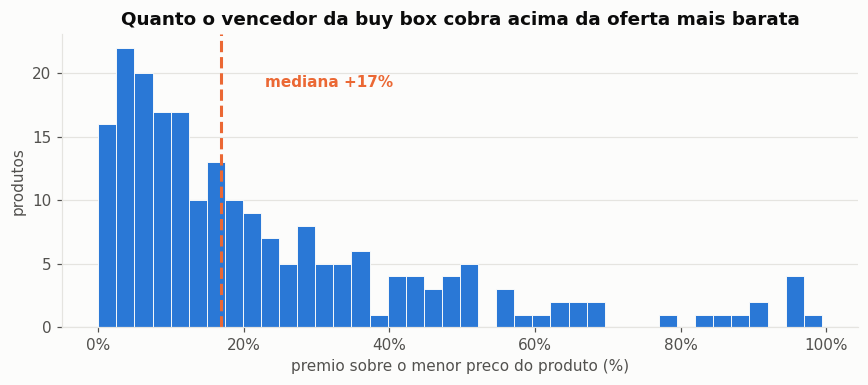


226 produtos (22% do total) em que existe
espaco comprovado para cobrar mais e AINDA assim deter a buy box.


In [9]:
fig, ax = plt.subplots(figsize=(8, 3.6))
dados = premium["premio"].to_numpy()
dados = dados[dados <= 100]
ax.hist(dados, bins=40, color=AZUL, edgecolor="#fcfcfb", linewidth=0.6)
med = float(premium["premio"].median())
ax.axvline(med, color=LARANJA, linewidth=2, linestyle="--")
ax.annotate(f"mediana +{med:.0f}%", xy=(med, ax.get_ylim()[1]*0.82),
            xytext=(med + 6, ax.get_ylim()[1]*0.82), color=LARANJA, fontweight="bold")
ax.set_title("Quanto o vencedor da buy box cobra acima da oferta mais barata")
ax.set_xlabel("premio sobre o menor preco do produto (%)")
ax.set_ylabel("produtos")
ax.xaxis.set_major_formatter(PercentFormatter())
limpa(ax); plt.tight_layout(); plt.show()

print(f"\n{premium.height} produtos ({100*premium.height/h1.height:.0f}% do total) em que existe")
print("espaco comprovado para cobrar mais e AINDA assim deter a buy box.")

**Veredito: H1 confirmada.** Em 22% dos produtos o vencedor cobra mais que o rival mais barato,
com mediana de +17%. O ranking da buy box pondera outra coisa alem de preco - e a proxima secao
mede o que e, e quanto vale.

Isso derruba a premissa implicita da estrategia `beat_winner` (bater o preco do vencedor por
R$ 0,01), que trata o problema como leilao de primeiro preco.

---
## 4. H2 - Atributos operacionais tem preco-sombra

Se preco nao explica tudo, o que explica? A dificuldade e que produtos diferentes tem niveis de
preco diferentes, entao comparar ofertas entre produtos e ruido puro.

**Metodo: logit condicional com efeito fixo por produto.** Cada `catalog_product_id` e um grupo;
o modelo so usa variacao *dentro* do mesmo produto, comparando ofertas que disputam exatamente a
mesma buy box. Isso elimina por construcao qualquer diferenca de categoria, marca, sazonalidade
ou nivel de preco.

In [10]:
from statsmodels.discrete.conditional_models import ConditionalLogit

teto = dedup["price"].quantile(0.995)          # corta o preco-barreira da secao 2.2
base = (comp.filter(pl.col("price") <= teto)
            .join(dedup.group_by("catalog_product_id").len()
                       .filter((pl.col("len") >= 2) & (pl.col("len") <= 100))
                       .select("catalog_product_id"), on="catalog_product_id"))

base = base.with_columns([
    (pl.col("shipping_logistic_type") == "fulfillment").cast(pl.Int8).alias("full"),
    pl.col("official_store_id").is_not_null().cast(pl.Int8).alias("oficial"),
    pl.col("shipping_free").cast(pl.Int8).alias("frete_gratis"),
    (pl.col("listing_type_id") == "gold_pro").cast(pl.Int8).alias("gold_pro"),
    (pl.col("rank") == 0).cast(pl.Int8).alias("y"),
    pl.col("price").median().over("catalog_product_id").alias("p_med"),
])
base = base.with_columns(np.log(base["price"] / base["p_med"]).alias("log_preco_rel"))

# grupos precisam ter exatamente 1 vencedor e >=2 ofertas
val = (base.group_by("catalog_product_id")
           .agg(pl.col("y").sum().alias("s"), pl.len().alias("n"))
           .filter((pl.col("s") == 1) & (pl.col("n") >= 2)))
base = base.join(val.select("catalog_product_id"), on="catalog_product_id")

REG = ["log_preco_rel", "full", "oficial", "frete_gratis", "gold_pro"]
pdf = base.select(REG + ["y", "catalog_product_id"]).to_pandas()
modelo = ConditionalLogit(pdf["y"], pdf[REG], groups=pdf["catalog_product_id"]).fit(disp=0)
print(f"amostra: {len(pdf):,} ofertas em {pdf.catalog_product_id.nunique():,} produtos\n")
print(modelo.summary())

amostra: 13,108 ofertas em 1,003 produtos

                  Conditional Logit Model Regression Results                  
Dep. Variable:                      y   No. Observations:                13108
Model:               ConditionalLogit   No. groups:                       1003
Log-Likelihood:               -1107.6   Min group size:                      2
Method:                          BFGS   Max group size:                     99
Date:                Sat, 12 Sep 2026   Mean group size:                  13.1
Time:                        20:33:30                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
log_preco_rel    -9.7005      0.412    -23.526      0.000     -10.509      -8.892
full              0.7921      0.107      7.410      0.000       0.583       1.002
oficial           0.9404      0.115      8.157      0.000       0.714       

### 4.1 Traduzindo coeficientes para reais

Um coeficiente de logit nao diz nada a um gerente comercial. A traducao util e o **preco-sombra**:
*quanto a mais posso cobrar, tendo o atributo, para ficar com a mesma probabilidade de buy box?*

Na indiferenca, o ganho do atributo compensa exatamente a perda de subir preco:

$$\beta_{preco}\cdot\Delta\ln(p) + \beta_{atributo} = 0
\quad\Longrightarrow\quad
\frac{\Delta p}{p} = \exp\!\left(\frac{\beta_{atributo}}{-\beta_{preco}}\right) - 1$$

**Nota de inferencia.** O preco-sombra e uma *razao* de dois coeficientes estimados. O intervalo
de confianca nao pode ser obtido transformando so os extremos do IC de $\beta_{atributo}$ - isso
trataria $\beta_{preco}$ como conhecido e ignoraria $\mathrm{Cov}(\beta_{atributo},\beta_{preco})$.
O IC abaixo usa **delta method** sobre a razao. Aqui a diferenca e pequena, porque os betas saem
quase ortogonais e $\beta_{preco}$ e estimado com precisao - mas com correlacao alta o IC ingenuo
enganaria, entao a correcao fica registrada.

In [11]:
b  = dict(zip(REG, modelo.params))
se = dict(zip(REG, modelo.bse))
V  = np.asarray(modelo.cov_params())
ix = {k: i for i, k in enumerate(REG)}
bp = b["log_preco_rel"]                      # negativo
iP = ix["log_preco_rel"]

def premio_ic(k):
    # theta = -b_k/b_preco e RAZAO de dois estimadores. Transformar so os
    # extremos do IC de b_k trataria b_preco como conhecido e ignoraria
    # Cov(b_k, b_preco) -> IC pelo delta method.
    th  = -b[k] / bp
    d_k = -1.0 / bp                          # d(theta)/d(b_k)
    d_p =  b[k] / bp**2                      # d(theta)/d(b_preco)
    var = (d_k**2 * V[ix[k], ix[k]]
           + d_p**2 * V[iP, iP]
           + 2 * d_k * d_p * V[ix[k], iP])
    sd = np.sqrt(var)
    f = lambda t: (np.exp(t) - 1) * 100
    return f(th), f(th - 1.96*sd), f(th + 1.96*sd)

rotulos = {"full": "Logistica FULL", "oficial": "Loja oficial",
           "gold_pro": "Anuncio Premium", "frete_gratis": "Frete gratis"}

print(f"elasticidade-preco da vitoria: beta = {bp:.2f}")
print("(muito alta: dentro do mesmo produto, preco domina - mas nao decide sozinho)")
print()
print("correlacao entre beta_preco e cada beta de atributo (entra no IC da razao):")
for k in ["full", "oficial", "gold_pro"]:
    r = V[iP, ix[k]] / np.sqrt(V[iP, iP] * V[ix[k], ix[k]])
    print(f"  {rotulos[k]:<18} {r:+.3f}")
print()
print(f"{'atributo':<18}{'preco-sombra':>14}   {'IC 95% (delta)':<24}significante")
print("-" * 70)
linhas = []
for k in ["full", "oficial", "gold_pro", "frete_gratis"]:
    pr, lo, hi = premio_ic(k)
    sig = "sim" if abs(b[k]/se[k]) > 1.96 else "NAO"
    print(f"{rotulos[k]:<18}{pr:>+13.2f}%   [{lo:+.1f}%, {hi:+.1f}%]{'':<7}{sig}")
    linhas.append((rotulos[k], pr, lo, hi, sig))
print("-" * 70)
print(f"{'FULL + loja oficial':<18}{(np.exp(-(b['full']+b['oficial'])/bp)-1)*100:>+13.2f}%")

elasticidade-preco da vitoria: beta = -9.70
(muito alta: dentro do mesmo produto, preco domina - mas nao decide sozinho)

correlacao entre beta_preco e cada beta de atributo (entra no IC da razao):
  Logistica FULL     +0.004
  Loja oficial       -0.158
  Anuncio Premium    +0.063

atributo            preco-sombra   IC 95% (delta)          significante
----------------------------------------------------------------------
Logistica FULL            +8.51%   [+6.1%, +11.0%]       sim
Loja oficial             +10.18%   [+7.6%, +12.8%]       sim
Anuncio Premium           -5.66%   [-7.7%, -3.5%]       sim
Frete gratis              -2.28%   [-5.7%, +1.3%]       NAO
----------------------------------------------------------------------
FULL + loja oficial       +19.55%


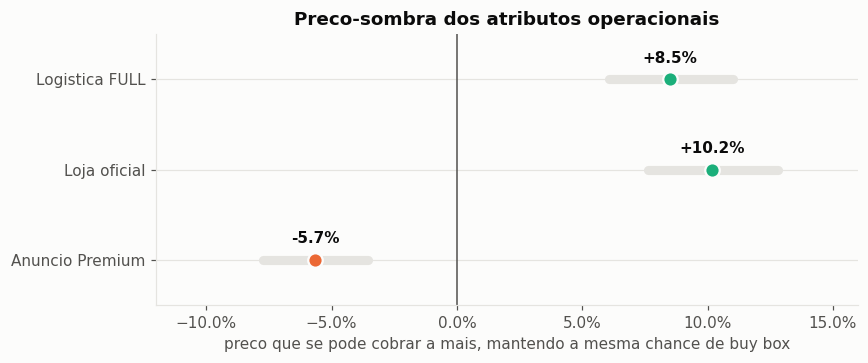

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.4))
sig = [l for l in linhas if l[4] == "sim"]
y = np.arange(len(sig))[::-1]
cores = [AQUA if l[1] > 0 else LARANJA for l in sig]
for i, (nome, p, lo, hi, _) in zip(y, sig):
    ax.plot([lo, hi], [i, i], color=GRADE, linewidth=6, solid_capstyle="round", zorder=1)
    ax.scatter([p], [i], s=90, color=cores[list(y).index(i)], zorder=3,
               edgecolor="#fcfcfb", linewidth=1.5)
    ax.annotate(f"{p:+.1f}%", xy=(p, i), xytext=(0, 11), textcoords="offset points",
                ha="center", fontweight="bold", color=TINTA, fontsize=10)
ax.axvline(0, color=TINTA2, linewidth=1, zorder=2)
ax.set_yticks(y); ax.set_yticklabels([l[0] for l in sig])
ax.set_xlabel("preco que se pode cobrar a mais, mantendo a mesma chance de buy box")
ax.set_title("Preco-sombra dos atributos operacionais")
ax.xaxis.set_major_formatter(PercentFormatter())
ax.set_xlim(-12, 16); ax.margins(y=0.25)
limpa(ax); plt.tight_layout(); plt.show()

**Veredito: H2 confirmada.** Tres atributos movem a buy box de forma estatisticamente solida:

- **FULL vale +8,5%** (IC95% 6,1% a 11,0%, delta method). Migrar um SKU para FULL permite subir o preco em ~8,5%
  sem perder nada de exposicao - e isso vai direto pra margem.
- **Loja oficial vale +10,2%**, mas nao e uma alavanca de curto prazo (depende de credenciamento
  de marca). Serve como diagnostico de contra quem se esta competindo.
- **Anuncio Premium (`gold_pro`) custa -5,7%.** O Premium cobra comissao maior *e* prejudica o
  ranking - esta se pagando duas vezes pelo mesmo anuncio. Como 38% das ofertas da base sao
  Premium, e uma ineficiencia difundida no mercado.
- **Frete gratis nao tem efeito** (p = 0,21). Dado que frete gratis custa caro ao vendedor,
  esse achado sozinho ja e economicamente relevante: e um custo sem retorno de ranking mensuravel.

> **Cuidado causal.** Isto e observacional: FULL nao foi sorteado entre vendedores. O efeito fixo
> por produto remove confundimento de produto/categoria, mas nao remove diferencas *entre
> vendedores* (quem adere ao FULL tende a ser mais estruturado). O numero deve ser lido como
> **teto plausivel**, e validado com o teste da secao 9.

---
## 5. H3 - Exposicao e um ativo duravel

A pergunta do cliente e sobre *tempo* de exposicao. Isso exige o painel, nao um snapshot.
Reconstruo o vencedor diario de cada produto ao longo de 22 dias.

In [13]:
quadros = []
for k in chaves:
    dia = k.split("date=")[1][:10]
    d1 = pl.read_parquet(io.BytesIO(download_bytes(k)))
    # mesma regra da secao 2.1b, dia a dia: o painel cruza snapshots de antes e
    # depois da mudanca de coleta, entao a coluna pode faltar em parte dos dias
    if "product_type" not in d1.columns:
        d1 = d1.with_columns(pl.lit("PRODUCT").alias("product_type"))
    d1 = d1.filter(pl.col("product_type") == "PRODUCT")
    d1 = d1.filter(pl.col("rank") == 0).unique(subset=["catalog_product_id"], keep="first")
    quadros.append(d1.select(["catalog_product_id", "seller_id", "price", "shipping_logistic_type"])
                     .with_columns(pl.lit(dia).alias("dia")))
painel = pl.concat(quadros).sort(["catalog_product_id", "dia"])
print(f"painel: {painel.height:,} observacoes produto-dia | {painel['dia'].n_unique()} dias")

painel: 30,910 observacoes produto-dia | 22 dias


In [14]:
painel = painel.with_columns([
    pl.col("seller_id").shift(1).over("catalog_product_id").alias("ant"),
    (pl.col("shipping_logistic_type") == "fulfillment").alias("full"),
])
tr = painel.filter(pl.col("ant").is_not_null())
ret = float((tr["seller_id"] == tr["ant"]).mean())

print("=== retencao diaria da buy box ===")
print(f"  P(continuo vencendo amanha | venci hoje) = {100*ret:.1f}%")
print(f"  transicoes observadas ................... {tr.height:,}")
print(f"  duracao media implicada ................. {1/(1-ret):.1f} dias\n")

print("=== retencao por logistica do vencedor ===")
dur = {}
for v in (True, False):
    s = tr.filter(pl.col("full") == v)
    r = float((s["seller_id"] == s["ant"]).mean())
    dur[v] = 1/(1-r)
    print(f"  {'FULL    ' if v else 'nao-FULL'}  retencao {100*r:.1f}%  ->  {dur[v]:.1f} dias de posse")
print(f"\n  FULL sustenta a buy box {100*(dur[True]/dur[False]-1):.0f}% mais tempo")

est = (painel.group_by("catalog_product_id")
             .agg(pl.col("seller_id").n_unique().alias("donos"), pl.len().alias("dias"))
             .filter(pl.col("dias") >= 10))
print(f"\n=== concentracao ({est.height:,} produtos com >=10 dias) ===")
print(f"  1 unico dono em todo o periodo: {(est['donos']==1).sum():,} ({100*(est['donos']==1).sum()/est.height:.0f}%)")
print(f"  5 ou mais donos ..............: {(est['donos']>=5).sum():,} ({100*(est['donos']>=5).sum()/est.height:.0f}%)")

=== retencao diaria da buy box ===
  P(continuo vencendo amanha | venci hoje) = 87.0%
  transicoes observadas ................... 25,655
  duracao media implicada ................. 7.7 dias

=== retencao por logistica do vencedor ===
  FULL      retencao 89.9%  ->  9.9 dias de posse
  nao-FULL  retencao 84.2%  ->  6.3 dias de posse

  FULL sustenta a buy box 57% mais tempo

=== concentracao (1,136 produtos com >=10 dias) ===
  1 unico dono em todo o periodo: 538 (47%)
  5 ou mais donos ..............: 82 (7%)


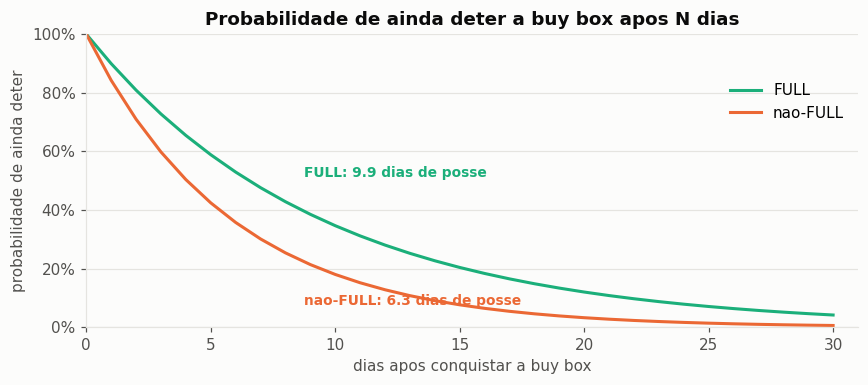

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.6))
t = np.arange(0, 31)
for v, cor, nome, dy in ((True, AQUA, "FULL", 16), (False, LARANJA, "nao-FULL", -34)):
    s = tr.filter(pl.col("full") == v)
    r = float((s["seller_id"] == s["ant"]).mean())
    ax.plot(t, r**t, color=cor, label=nome)
    # rotulo direto em x=8, onde as curvas ja se separaram
    ax.annotate(f"{nome}: {1/(1-r):.1f} dias de posse", xy=(8, r**8), xytext=(12, dy),
                textcoords="offset points", color=cor, fontweight="bold", fontsize=9)
ax.set_title("Probabilidade de ainda deter a buy box apos N dias")
ax.set_xlabel("dias apos conquistar a buy box"); ax.set_ylabel("probabilidade de ainda deter")
ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.set_xlim(0, 31); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.88))
limpa(ax); plt.tight_layout(); plt.show()

In [16]:
pp = (painel.with_columns(pl.col("price").shift(1).over("catalog_product_id").alias("p_ant"))
            .filter(pl.col("p_ant").is_not_null() & (pl.col("seller_id") != pl.col("ant")))
            .with_columns(((pl.col("price")/pl.col("p_ant") - 1) * 100).alias("var")))
print("=== quando a buy box troca de dono ===")
print(f"  trocas: {pp.height:,} ({100*pp.height/tr.height:.1f}% das transicoes)")
print(f"  variacao de preco do vencedor: mediana {pp['var'].median():+.1f}%")
print(f"  trocas em que o NOVO vencedor esta MAIS CARO: {100*(pp['var']>0).mean():.0f}%")
print("\n  -> metade das trocas NAO e guerra de preco. Reforca H2: quem toma a buy box")
print("     frequentemente o faz por atributo, nao por desconto.")

=== quando a buy box troca de dono ===
  trocas: 3,340 (13.0% das transicoes)
  variacao de preco do vencedor: mediana +0.0%
  trocas em que o NOVO vencedor esta MAIS CARO: 50%

  -> metade das trocas NAO e guerra de preco. Reforca H2: quem toma a buy box
     frequentemente o faz por atributo, nao por desconto.


**Veredito: H3 confirmada.** A buy box e pegajosa: 87,0% de retencao diaria, ~7,7 dias de posse
media, e 47% dos produtos tiveram um unico dono em 22 dias.

Isso muda a economia da decisao. Se ganhar a buy box durasse um dia, pagar caro para conquista-la
nao se justificaria. Durando ~7,7 dias - e ~9,9 dias com FULL - **o investimento em conquista se
amortiza sobre toda a posse**. E o mesmo argumento reforca a assimetria: perder a buy box tambem
custa uma semana de exposicao, nao um dia.

---
## 6. O elo que falta: custo de fornecedor e o piso real

Tudo acima diz respeito a *ganhar*. Ganhar vendendo no prejuizo e facil e inutil. Esta secao
introduz a estrutura de custo.

$$\text{margem}(p) = p\cdot(1-c) - f(p) - s(p) - C$$

onde $c$ = comissao, $f$ = taxa fixa, $s$ = frete por conta do vendedor, $C$ = **custo de compra**.

> **Os parametros abaixo sao premissas a confirmar com o cliente.** A estrutura de tarifas do ML
> varia por categoria e muda ao longo do tempo. O valor do modelo esta na estrutura, nao nos
> numeros default - todos estao isolados numa celula so, para o cliente substituir.

In [17]:
# ============ PARAMETROS A CONFIRMAR COM O CLIENTE ============
COMISSAO_CLASSICO = 0.11    # gold_special
COMISSAO_PREMIUM  = 0.16    # gold_pro
TAXA_FIXA         = 6.25    # por unidade, para anuncios abaixo do limiar
LIMIAR_FRETE      = 79.00   # acima disso o frete gratis passa a ser obrigatorio/subsidiado
CUSTO_FRETE       = 19.90   # custo medio do frete subsidiado
# ==============================================================

def margem(p, custo, premium=False, taxa_full=0.0):
    com = COMISSAO_PREMIUM if premium else COMISSAO_CLASSICO
    fixa = TAXA_FIXA if p < LIMIAR_FRETE else 0.0
    frete = CUSTO_FRETE if p >= LIMIAR_FRETE else 0.0
    return p*(1 - com) - fixa - frete - custo - taxa_full

def break_even(custo, premium=False, taxa_full=0.0):
    # menor preco que ainda cobre o custo total; trata a descontinuidade no limiar
    com = COMISSAO_PREMIUM if premium else COMISSAO_CLASSICO
    p_baixo = (custo + taxa_full + TAXA_FIXA) / (1 - com)
    if p_baixo < LIMIAR_FRETE:
        return p_baixo
    p_alto = (custo + taxa_full + CUSTO_FRETE) / (1 - com)
    return max(p_alto, LIMIAR_FRETE)

print("break-even por custo de compra (anuncio Classico, sem FULL):\n")
print(f"{'custo':>8}{'break-even':>14}{'markup minimo':>16}")
for c in (10, 20, 30, 50, 80, 120):
    be = break_even(c)
    print(f"R$ {c:>5.2f}   R$ {be:>8.2f}   {100*(be/c - 1):>11.0f}%")

break-even por custo de compra (anuncio Classico, sem FULL):

   custo    break-even   markup minimo
R$ 10.00   R$    18.26            83%
R$ 20.00   R$    29.49            47%
R$ 30.00   R$    40.73            36%
R$ 50.00   R$    63.20            26%
R$ 80.00   R$   112.25            40%
R$ 120.00   R$   157.19            31%


In [18]:
import yaml
cfg = yaml.safe_load(open(os.path.join(ETL, "config", "mock_client.yaml"), encoding="utf-8"))

def custo_implicito(preco, premium=False):
    # inverte: que custo de compra torna este preco exatamente o break-even?
    com = COMISSAO_PREMIUM if premium else COMISSAO_CLASSICO
    fixa = TAXA_FIXA if preco < LIMIAR_FRETE else 0.0
    frete = CUSTO_FRETE if preco >= LIMIAR_FRETE else 0.0
    return preco*(1 - com) - fixa - frete

print("=== que custo de fornecedor o min_price atual assume? ===\n")
print(f"{'SKU':<14}{'preco':>9}{'min_price':>11}{'custo implicito':>17}")
print("-" * 51)
for s in cfg["skus"]:
    print(f"{s['sku']:<14}{s['current_price']:>9.2f}{s['min_price']:>11.2f}{custo_implicito(s['min_price']):>17.2f}")
print("-" * 51)
print("\nLeitura: o min_price so faz sentido se o custo de compra for EXATAMENTE esse valor.")
print("Se o custo real for menor, o piso esta alto demais e esta bloqueando venda lucrativa -")
print("que e o diagnostico compativel com 3 dos 4 SKUs presos em 'losing_locked'.")

=== que custo de fornecedor o min_price atual assume? ===

SKU               preco  min_price  custo implicito
---------------------------------------------------
SR-INOX-001       39.90      22.00            13.33
RALD-INOX-4F      59.90      46.00            34.69
CAB-MDR-20       129.90      72.00            57.83
LUM-PIXAR        109.90      68.00            54.27
---------------------------------------------------

Leitura: o min_price so faz sentido se o custo de compra for EXATAMENTE esse valor.
Se o custo real for menor, o piso esta alto demais e esta bloqueando venda lucrativa -
que e o diagnostico compativel com 3 dos 4 SKUs presos em 'losing_locked'.


---
## 7. O otimizador: juntando probabilidade e margem

Com $P(\text{buy box}\mid p)$ da secao 4 e $\text{margem}(p)$ da secao 6, o lucro esperado e:

$$\mathbb{E}[\text{lucro}](p) = P(\text{buy box}\mid p)\times \text{margem}(p)\times V$$

**Propriedade util:** o volume $V$ e um multiplicador constante, entao **nao afeta o preco otimo**.
Da para otimizar sem saber quanto o SKU vende - o que importa porque essa e justamente a variavel
que nao temos.

O logit condicional da a probabilidade na forma multinomial: contra o conjunto real de
concorrentes hoje,

$$P(\text{nossa oferta vence}) = \frac{e^{V_{nos}}}{e^{V_{nos}} + \sum_j e^{V_j}}$$

In [19]:
def monta_mercado(pid):
    mk = dedup.filter(pl.col("catalog_product_id") == pid)
    if mk.height == 0:
        return None
    p_med = float(mk["price"].median())
    r = mk.with_columns([
        (pl.col("shipping_logistic_type") == "fulfillment").cast(pl.Int8).alias("f"),
        pl.col("official_store_id").is_not_null().cast(pl.Int8).alias("o"),
        (pl.col("listing_type_id") == "gold_pro").cast(pl.Int8).alias("g"),
        pl.col("shipping_free").cast(pl.Int8).alias("fr"),
    ])
    V = (b["log_preco_rel"]*np.log(r["price"].to_numpy()/p_med) + b["full"]*r["f"].to_numpy()
         + b["oficial"]*r["o"].to_numpy() + b["gold_pro"]*r["g"].to_numpy()
         + b["frete_gratis"]*r["fr"].to_numpy())
    return p_med, np.exp(V).sum(), mk

def p_vitoria(p, p_med, soma_riv, full=0, oficial=0, premium=0, frete=1):
    V = (b["log_preco_rel"]*np.log(p/p_med) + b["full"]*full + b["oficial"]*oficial
         + b["gold_pro"]*premium + b["frete_gratis"]*frete)
    return np.exp(V) / (np.exp(V) + soma_riv)

SKU = next(s for s in cfg["skus"] if s["sku"] == "RALD-INOX-4F")
merc = monta_mercado(SKU["catalog_product_id"])
p_med, soma_riv, mk = merc
print(f"SKU: {SKU['sku']} — {SKU['product_hint']}")
print(f"concorrentes no snapshot de hoje: {mk.height}\n")
print(mk.sort("rank").select(["rank","price","shipping_logistic_type","listing_type_id"])
        .head(6).to_pandas().to_string(index=False))

SKU: RALD-INOX-4F — Ralador Manual Aco Inox Ke Home 4 faces
concorrentes no snapshot de hoje: 11

 rank  price shipping_logistic_type listing_type_id
    0  44.95            fulfillment    gold_special
    1  45.00            fulfillment    gold_special
    2  46.59          cross_docking    gold_special
    3  48.90          cross_docking    gold_special
    4  49.99            xd_drop_off    gold_special
    5  49.99            xd_drop_off    gold_special


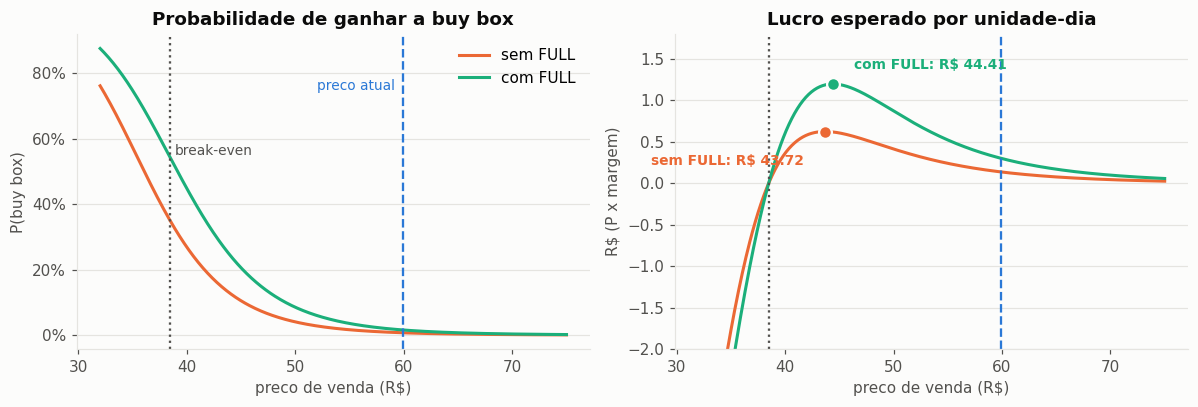

custo de compra assumido: R$ 28.00 | break-even: R$ 38.48

cenario       preco otimo   P(buy box)    margem   E[lucro]
-----------------------------------------------------------
sem FULL            43.72        13.4%      4.66       0.63
com FULL            44.41        22.7%      5.27       1.20
hoje                59.90         0.7%     19.06       0.14
-----------------------------------------------------------

ganho do preco otimo sobre o preco de hoje: 4.5x
ganho adicional de migrar para FULL ......: 1.92x


In [20]:
CUSTO = 28.00   # premissa: custo de compra do SKU. TROCAR pelo numero real do cliente.

grade = np.linspace(32, 75, 500)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

melhores = {}
for full, cor, nome, dx, dy, al in ((0, LARANJA, "sem FULL", -14, -22, "right"),
                                   (1, AQUA, "com FULL", 14, 10, "left")):
    pw = np.array([p_vitoria(p, p_med, soma_riv, full=full) for p in grade])
    mg = np.array([margem(p, CUSTO) for p in grade])
    ev = pw * mg
    i = int(ev.argmax()); melhores[nome] = (grade[i], pw[i], mg[i], ev[i])

    axes[0].plot(grade, pw, color=cor, label=nome)
    axes[1].plot(grade, ev, color=cor, label=nome)
    axes[1].scatter([grade[i]], [ev[i]], s=70, color=cor, zorder=3,
                    edgecolor="#fcfcfb", linewidth=1.5)
    axes[1].annotate(f"{nome}: R$ {grade[i]:.2f}", xy=(grade[i], ev[i]), xytext=(dx, dy),
                     textcoords="offset points", ha=al, color=cor,
                     fontweight="bold", fontsize=9)

be = break_even(CUSTO)
for ax in axes:
    ax.axvline(be, color=TINTA2, linestyle=":", linewidth=1.5)
    ax.axvline(SKU["current_price"], color=AZUL, linestyle="--", linewidth=1.5)
axes[0].annotate("break-even", xy=(be, 0.55), xytext=(3, 0), textcoords="offset points",
                 color=TINTA2, fontsize=9)
axes[0].annotate("preco atual", xy=(SKU["current_price"], 0.75), xytext=(-5, 0),
                 textcoords="offset points", color=AZUL, fontsize=9, ha="right")
axes[0].set_title("Probabilidade de ganhar a buy box")
axes[0].set_ylabel("P(buy box)"); axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Lucro esperado por unidade-dia")
axes[1].set_ylabel("R$ (P x margem)")
axes[0].legend(frameon=False, loc="upper right")
for ax in axes:
    ax.set_xlabel("preco de venda (R$)"); limpa(ax)
axes[1].set_ylim(bottom=-2, top=1.8)   # folga no topo p/ rotulo; mergulho abaixo do break-even nao domina
plt.tight_layout(); plt.show()

print(f"custo de compra assumido: R$ {CUSTO:.2f} | break-even: R$ {be:.2f}\n")
print(f"{'cenario':<12}{'preco otimo':>13}{'P(buy box)':>13}{'margem':>10}{'E[lucro]':>11}")
print("-" * 59)
for nome, (p, pw, mg, ev) in melhores.items():
    print(f"{nome:<12}{p:>13.2f}{100*pw:>12.1f}%{mg:>10.2f}{ev:>11.2f}")
atual_pw = p_vitoria(SKU["current_price"], p_med, soma_riv, full=0)
atual_ev = atual_pw * margem(SKU["current_price"], CUSTO)
print(f"{'hoje':<12}{SKU['current_price']:>13.2f}{100*atual_pw:>12.1f}%"
      f"{margem(SKU['current_price'], CUSTO):>10.2f}{atual_ev:>11.2f}")
print("-" * 59)
print(f"\nganho do preco otimo sobre o preco de hoje: {melhores['sem FULL'][3]/atual_ev:.1f}x")
print(f"ganho adicional de migrar para FULL ......: {melhores['com FULL'][3]/melhores['sem FULL'][3]:.2f}x")

In [21]:
print("=== sensibilidade ao custo de compra ===")
print("(a variavel que hoje nao temos - por isso vale mapear a faixa toda)\n")
print(f"{'custo':>8}{'break-even':>12}{'p otimo':>10}{'P(bb)':>9}{'E[lucro]':>11}{'  veredito'}")
print("-" * 62)
for c in (15, 20, 25, 30, 35, 40):
    bec = break_even(c)
    ev = np.array([p_vitoria(p, p_med, soma_riv, full=0) * margem(p, c) for p in grade])
    i = int(ev.argmax())
    ver = "saudavel" if ev[i] > 1 else ("apertado" if ev[i] > 0.2 else "inviavel")
    print(f"R$ {c:>5.2f}{bec:>12.2f}{grade[i]:>10.2f}{100*p_vitoria(grade[i], p_med, soma_riv):>8.1f}%{ev[i]:>11.2f}   {ver}")
print("-" * 62)
print("\nAcima de ~R$ 35 de custo este SKU nao compete: o break-even encosta no preco")
print("do vencedor e nao sobra margem. A decisao deixa de ser de preco e passa a ser")
print("de compra - renegociar fornecedor ou descontinuar o item.")

=== sensibilidade ao custo de compra ===
(a variavel que hoje nao temos - por isso vale mapear a faixa toda)

   custo  break-even   p otimo    P(bb)   E[lucro]  veredito
--------------------------------------------------------------
R$ 15.00       23.88     33.81    65.2%       5.77   saudavel
R$ 20.00       29.49     36.57    46.7%       2.94   saudavel
R$ 25.00       35.11     40.62    24.1%       1.18   saudavel
R$ 30.00       40.73     45.96     8.7%       0.41   apertado
R$ 35.00       46.35     51.82     2.9%       0.14   inviavel
R$ 40.00       51.97     58.02     1.0%       0.05   inviavel
--------------------------------------------------------------

Acima de ~R$ 35 de custo este SKU nao compete: o break-even encosta no preco
do vencedor e nao sobra margem. A decisao deixa de ser de preco e passa a ser
de compra - renegociar fornecedor ou descontinuar o item.


---
## 8. Como isso gera valor para o cliente

Quatro produtos, em ordem de esforco:

### 8.1 Piso de margem calculado (substitui `min_price`)
Adicionar `custo_compra` por SKU no cadastro e derivar o piso de `break_even()`. Elimina os dois
erros possiveis do piso manual - vender no prejuizo e recusar venda lucrativa. **E pre-requisito
de tudo o mais**, e o unico item que depende de informacao que so o cliente tem.

### 8.2 Preco-alvo por lucro esperado (substitui `beat_winner`)
A estrategia atual persegue a buy box por R$ 0,01 abaixo do vencedor - trata o problema como
leilao de preco, o que a secao 3 refuta. Trocar por `argmax P(buy box|p) x margem(p)`. No exemplo
da secao 7, a diferenca entre o preco de hoje e o otimo e de **uma ordem de grandeza** em lucro
esperado.

### 8.3 Relatorio de alavancas nao-precificadas
O ativo mais vendavel da analise, porque nenhum concorrente entrega isso:

- **"Migrar este SKU para FULL vale +8,5% de preco"** - traduzido em reais por SKU, comparado ao
  custo de armazenagem do FULL. Decisao de investimento com numero, nao com intuicao.
- **"Sair de Premium para Classico vale +5,7% de ranking e ~5 p.p. de comissao"** - ganho dos dois
  lados. 38% do mercado esta pagando esse imposto.
- **"Frete gratis nao esta comprando ranking"** - custo sem retorno mensuravel.

### 8.4 Alerta de risco de perda com antecedencia
Com retencao de 87,0% e a probabilidade do modelo, da para detectar quando um SKU entra em zona
de risco *antes* de perder a buy box - e uma semana de exposicao. Monitoramento preventivo, nao
reativo.

---
## 9. Limitacoes - o que este notebook NAO prova

Honestidade sobre os limites e o que separa analise de marketing.

**1. Causalidade.** Observacional. O efeito fixo por produto elimina confundimento de
produto/categoria, mas nao diferencas entre vendedores. FULL pode estar em parte capturando
"vendedor mais profissional". **O +8,5% e teto plausivel, nao efeito causal medido.**

> **Teste que resolve:** migrar 2-3 SKUs para FULL mantendo preco, e medir a mudanca de posicao
> durante 2 semanas. Custa pouco e converte a estimativa em fato. E o proximo passo natural.

**2. Volume nao e observado.** Otimizamos lucro por *unidade vendida*, nao por dia. `visits_30d`
so existe para o vencedor, entao nao da para estimar conversao. O preco otimo esta correto sob
elasticidade de demanda constante; se a demanda propria do SKU for elastica, o otimo e mais baixo.

**3. A estrutura de tarifas e premissa.** Comissao, taxa fixa e frete sao defaults plausiveis,
nao valores auditados do contrato do cliente. Todos isolados numa celula.

**4. Concorrentes sao estaticos.** O otimizador assume que rivais nao reagem. Se o mercado tiver
outros repricers automaticos, o equilibrio se desloca - risco real de corrida ao fundo que os
guard rails de `min_price`/`max_change_pct` existem para conter.

**5. Amostra de 22 dias, sem ciclo sazonal.** Retencao de 87,0% e medida em periodo sem Black
Friday nem Natal. Sob promocao pesada a rotatividade deve subir.

**6. A carteira do cliente e mock, e o cliente real nao esta no catalogo.** Os 4 SKUs do
`mock_client.yaml` sao fake. O seller configurado (VARIEDADESSB) e real, mas vende inteiramente por
`USER_PRODUCT` - anuncio proprio, sem concorrencia na pagina. Ou seja, **as secoes 3 a 7 descrevem
um mercado em que ele nao compete**. O modelo vale para sellers de catalogo, que sao a maior parte
do mercado; para ele, o produto util e outro.

---
## 10. Proximos passos

| Prioridade | Acao | Depende de |
|---|---|---|
| 1 | Coletar `custo_compra` por SKU e ligar no piso | Cliente |
| 2 | Teste FULL em 2-3 SKUs com preco fixo (2 semanas) | Cliente |
| 3 | Trocar `beat_winner` por otimizacao de lucro esperado | Engenharia |
| 4 | Reestimar o modelo semanalmente; monitorar drift dos coeficientes | Engenharia |
| 5 | Incluir as categorias do cliente na watchlist | Engenharia |
| 6 | Registrar posicao intradiaria para medir exposicao em horas, nao dias | Engenharia |

**O ponto 6 e mais importante do que parece.** Hoje temos uma foto por dia; "tempo de exposicao"
e medido em granularidade de 24h. Como a buy box pode trocar varias vezes ao dia, a retencao de
87,0% e um limite superior do que o cliente realmente detem. Coleta intradiaria nos 4 SKUs
proprios e barata e transformaria a metrica central deste relatorio em algo exato.